# Time-strain inversion of the Hess 4D modeled post-stack seismic data (benchmark methods)

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import matplotlib.pyplot as plt
from pylops.avo.poststack import PoststackLinearModelling
from strainprox.utils import *
from pylops import CausalIntegration
from scipy.interpolate import interp1d
from pylops.basicoperators import Diagonal, FirstDerivative
from pylops.optimization.leastsquares import normal_equations_inversion
from pylops import Laplacian

## Data loading and visualization

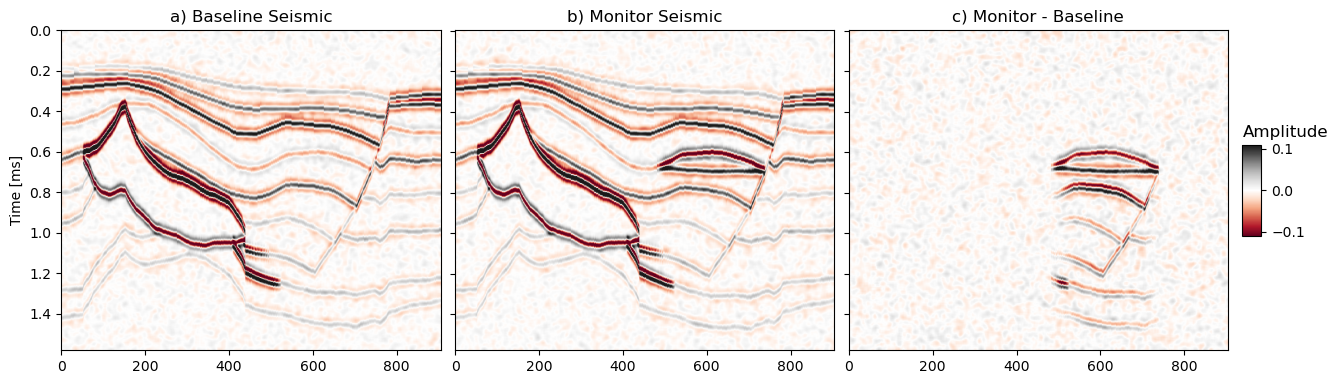

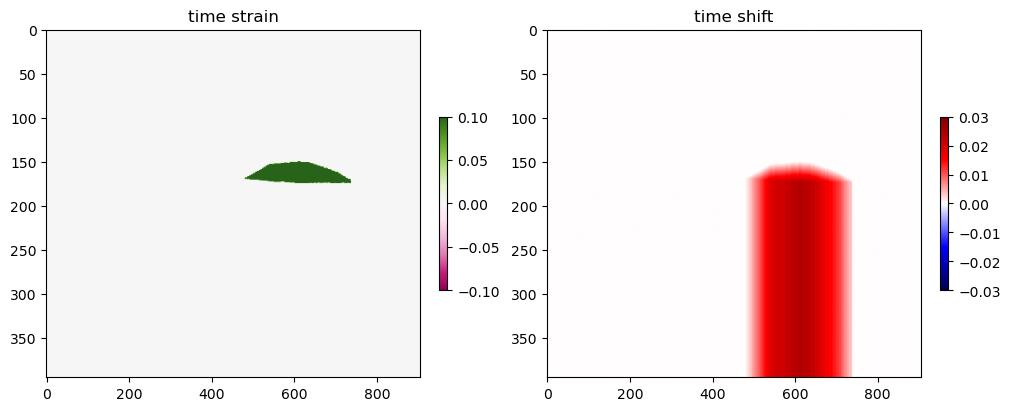

In [2]:
# We load the Hess 4D dataset which contains:
# - Baseline seismic data (d1)
# - Monitor seismic data (d2)
# - Wavelet (wav)
# - Ground truth strain (utrue)

dtype = 'float64'
hess = np.load('../data/Hess/Hess4d_time.npz')
wav = cp.asarray(hess['wav'].astype(np.float32))
d1 = cp.asarray(hess['dn1'].astype(np.float32))
d2 = cp.asarray(hess['dn2'].astype(np.float32))
utrue = cp.asarray(hess['straint'].astype(np.float32))
dims = utrue.shape
dt = 0.004
t = cp.arange(dims[0], dtype='float64') * dt
C = CausalIntegration(dims=dims, axis=0, sampling=dt, dtype=dtype)
plotter_4D(d1, d2, dt=dt, ztitle='Time [ms]', type='seismic')
strain_shift(strain=utrue, shift=C*utrue)

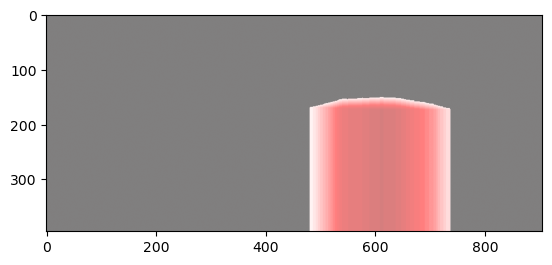

In [4]:
# Region of interest for metrics
roi_ = roi(cp.asnumpy(C*utrue))
plt.imshow(cp.asnumpy(C*utrue), cmap='seismic', vmin=-0.03, vmax=0.03)
plt.imshow(roi_, cmap='gray', alpha=0.5)

## Time-shift inversion

$$
\Delta \tau_i = \argmin_{\Delta \tau_i} ||d_1(t) - (d_2(t+ \tau_{i-1}) - J_{d_2}\Delta \tau)||^2 + \epsilon^2 ||\nabla^2 (\tau_{i-1} + \Delta \tau)||^2_2
$$

iter 001 | total = 62.601 | data = 61.072 | reg = 1.528 | step = 0.260 | shift_global_rmse = 0.007 | shift_global_mae = 0.003 | shift_roi_rmse = 0.017 | shift_roi_mae = 0.015 | shift_bg_leakage = 0.000 | shift_dice = 0.196 | strain_global_rmse = 0.029 | strain_global_mae = 0.008 | strain_roi_rmse = 0.238 | strain_roi_mae = 0.229 | strain_bg_leakage = 0.012 | strain_dice = 0.162


iter 011 | total = 46.905 | data = 44.942 | reg = 1.963 | step = 0.079 | shift_global_rmse = 0.006 | shift_global_mae = 0.002 | shift_roi_rmse = 0.014 | shift_roi_mae = 0.012 | shift_bg_leakage = 0.000 | shift_dice = 0.789 | strain_global_rmse = 0.031 | strain_global_mae = 0.012 | strain_roi_rmse = 0.177 | strain_roi_mae = 0.165 | strain_bg_leakage = 0.024 | strain_dice = 0.117
iter 021 | total = 43.656 | data = 42.013 | reg = 1.643 | step = 0.056 | shift_global_rmse = 0.005 | shift_global_mae = 0.002 | shift_roi_rmse = 0.012 | shift_roi_mae = 0.010 | shift_bg_leakage = 0.001 | shift_dice = 0.848 | strain_global_rmse = 0.028 | strain_global_mae = 0.013 | strain_roi_rmse = 0.135 | strain_roi_mae = 0.126 | strain_bg_leakage = 0.023 | strain_dice = 0.107
iter 031 | total = 41.920 | data = 40.368 | reg = 1.552 | step = 0.043 | shift_global_rmse = 0.004 | shift_global_mae = 0.002 | shift_roi_rmse = 0.011 | shift_roi_mae = 0.009 | shift_bg_leakage = 0.001 | shift_dice = 0.838 | strain_global

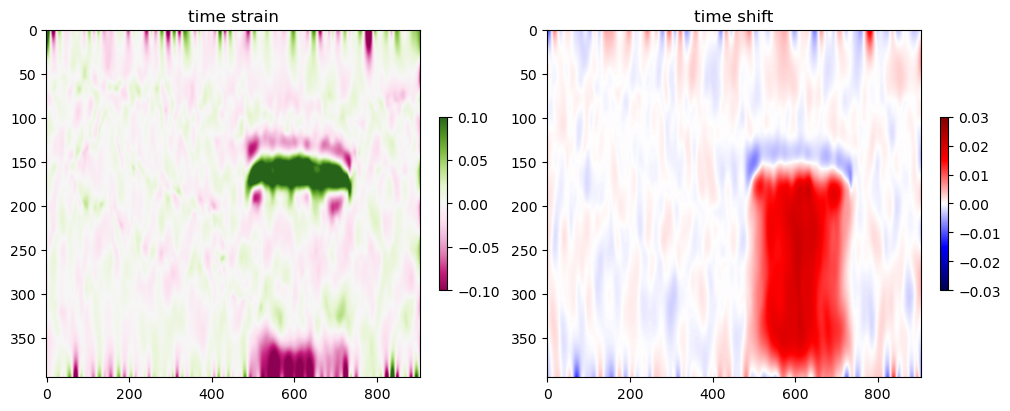

In [6]:
eps = 5e2
outeriter = 200
inneriter = 100

D = FirstDerivative(dims=dims, axis=0, sampling=dt, dtype=dtype, edge=True)
D2op = Laplacian(dims, weights=[10, 1])

# Initialize variables
taui = cp.zeros(np.prod(dims))
d2i = d2.copy()
gt_shift = C * utrue.reshape(dims)
gt_strain = utrue.reshape(dims)

metric_keys = ['global_mae', 'global_rmse', 'roi_mae', 'roi_rmse', 'bg_leakage', 'dice']
history = {k: [] for k in [
    'loss_total', 'loss_data', 'loss_reg',
    *[f'shift_{k}' for k in metric_keys],
    *[f'strain_{k}' for k in metric_keys],
]}

start_time = time.perf_counter()
for i in range(outeriter):
    d = d1.ravel() - d2i.ravel()
    J = Diagonal(D * d2i, dtype=dtype)
    lu = D2op * taui

    dtau = normal_equations_inversion(
        Op=J, y=d,
        Regs=[D2op],
        x0=cp.zeros(np.prod(dims)),
        dataregs=[-lu],
        epsRs=[np.sqrt(eps)],
        niter=inneriter)[0]
    
    # Update tau
    taui += dtau
    # Update shifted data with new tau
    d2i = apply_time_shift_cupy(d=d2, time_shift=taui, t=t, dims=dims)

    # -------- Evaluate nonlinear objective after update and metrics -----------
    data_term = float(cp.linalg.norm(d1.ravel() - d2i.ravel()) ** 2)
    reg_term = eps * float(cp.linalg.norm(D2op * taui) ** 2)
    history['loss_data'].append(data_term)
    history['loss_reg'].append(reg_term)
    history['loss_total'].append(data_term + reg_term)

    pred_shift = taui.reshape(dims)
    pred_strain = D * pred_shift
    shift_metrics = compute_all_metrics(pred=pred_shift, gt=gt_shift, alpha=0.05)
    strain_metrics = compute_all_metrics(pred=pred_strain, gt=gt_strain, alpha=0.05)
    for k, v in shift_metrics.items():
        history[f'shift_{k}'].append(v)
    for k, v in strain_metrics.items():
        history[f'strain_{k}'].append(v)

    if i % 10 == 0:
        print(
            f"iter {i+1:03d} | "
            f"total = {data_term + reg_term:.3f} | "
            f"data = {data_term:.3f} | "
            f"reg = {reg_term:.3f} | "
            f"step = {np.linalg.norm(dtau):.3f} | "
            + " | ".join(f"shift_{k} = {v:.3f}" for k, v in shift_metrics.items())
            + " | "
            + " | ".join(f"strain_{k} = {v:.3f}" for k, v in strain_metrics.items())
        )

total_time = time.perf_counter() - start_time
print(f'Total time {total_time/60:.2f} minutes')

pred_shift_np = cp.asnumpy(pred_shift)
pred_strain_np = cp.asnumpy(pred_strain)
d2i_np = cp.asnumpy(d2i)

strain_shift(strain=pred_strain_np, shift=pred_shift_np)

np.savez(
    '../results/hess/time_shift_tk.npz',
    shift=pred_shift,
    strain=pred_strain,
    d2s=d2i,
    **{k: np.array(v) for k, v in history.items()},
)

## Time strain inversion - Smooth prior - data term


$$
     \Delta u = \argmin_{\Delta u}\Vert d_1(t) - d_2(t+ dt C  u_{i-1}) - G(u_{i-1}) -  (G + dt  J_{d_2} C) \Delta u \Vert^2  + \Vert \nabla^2 (\Delta u + u_{i-1})\Vert_{2}^2
$$

iter 001 | total = 60.743 | data = 56.699 | reg = 4.045 | step = 1.235 | shift_global_rmse = 0.006 | shift_global_mae = 0.002 | shift_roi_rmse = 0.014 | shift_roi_mae = 0.012 | shift_bg_leakage = 0.000 | shift_dice = 0.903 | strain_global_rmse = 0.025 | strain_global_mae = 0.004 | strain_roi_rmse = 0.230 | strain_roi_mae = 0.225 | strain_bg_leakage = 0.002 | strain_dice = 0.225
iter 011 | total = 39.624 | data = 36.673 | reg = 2.951 | step = 0.212 | shift_global_rmse = 0.002 | shift_global_mae = 0.001 | shift_roi_rmse = 0.004 | shift_roi_mae = 0.003 | shift_bg_leakage = 0.000 | shift_dice = 0.941 | strain_global_rmse = 0.021 | strain_global_mae = 0.005 | strain_roi_rmse = 0.179 | strain_roi_mae = 0.174 | strain_bg_leakage = 0.008 | strain_dice = 0.338
iter 021 | total = 38.650 | data = 35.779 | reg = 2.871 | step = 0.128 | shift_global_rmse = 0.002 | shift_global_mae = 0.001 | shift_roi_rmse = 0.004 | shift_roi_mae = 0.003 | shift_bg_leakage = 0.000 | shift_dice = 0.948 | strain_global

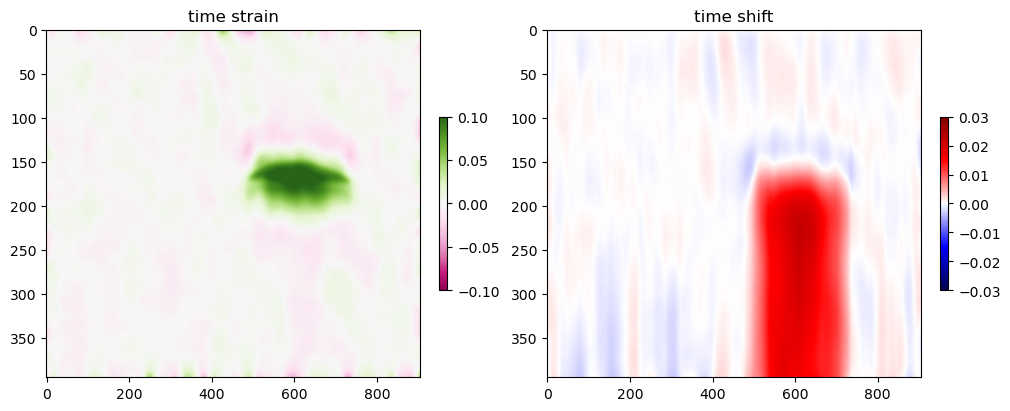

In [8]:
eps = 5e2
outeriter = 200
inneriter = 100

# Linear Operators
D = FirstDerivative(dims=dims, axis=0, sampling=dt, dtype=dtype)
G = PoststackLinearModelling(wav/2, nt0=dims[0], spatdims=dims[1:])
C = CausalIntegration(dims=dims, axis=0, sampling=dt, dtype=dtype)
D2op = Laplacian(dims, weights=[1, 1])

# Variables
ui = cp.zeros(np.prod(dims)) # time shift at iteration i
d2i = d2.copy() # Shifted monitor data at iteration i
gt_shift = C * utrue.reshape(dims)
gt_strain = utrue.reshape(dims)

metric_keys = ['global_mae', 'global_rmse', 'roi_mae', 'roi_rmse', 'bg_leakage', 'dice']
history = {k: [] for k in [
    'loss_total', 'loss_data', 'loss_reg',
    *[f'shift_{k}' for k in metric_keys],
    *[f'strain_{k}' for k in metric_keys],
]}

start_time = time.perf_counter()
for i in range(outeriter):
    d = d1.ravel() - d2i.ravel() - (G*ui)
    J = Diagonal(D*d2i, dtype=dtype)
    Op = G + J * C
    lu = D2op * ui

    du = normal_equations_inversion(
        Op=Op, y=d, 
        Regs=[D2op], 
        x0=cp.zeros(np.prod(dims)),
        dataregs=[-lu], 
        epsRs=[np.sqrt(eps)],
        **dict(niter=inneriter))[0] 
    # update u
    ui += du
    # Update shifted data with new u
    d2i = apply_time_shift_cupy(d=d2, time_shift=C*ui, t=t, dims=dims)
    
    # -------- Evaluate nonlinear objective after update and metrics -----------
    data_term = float(cp.linalg.norm(d - Op * du) ** 2)
    reg_term = eps * float(cp.linalg.norm(D2op * ui) ** 2)
    history['loss_data'].append(data_term)
    history['loss_reg'].append(reg_term)
    history['loss_total'].append(data_term + reg_term)

    pred_shift = C*ui.reshape(dims)
    pred_strain = ui.reshape(dims)
    shift_metrics = compute_all_metrics(pred=pred_shift, gt=gt_shift, alpha=0.05)
    strain_metrics = compute_all_metrics(pred=pred_strain, gt=gt_strain, alpha=0.05)
    for k, v in shift_metrics.items():
        history[f'shift_{k}'].append(v)
    for k, v in strain_metrics.items():
        history[f'strain_{k}'].append(v)

    if i % 10 == 0:
        print(
            f"iter {i+1:03d} | "
            f"total = {data_term + reg_term:.3f} | "
            f"data = {data_term:.3f} | "
            f"reg = {reg_term:.3f} | "
            f"step = {np.linalg.norm(du):.3f} | "
            + " | ".join(f"shift_{k} = {v:.3f}" for k, v in shift_metrics.items())
            + " | "
            + " | ".join(f"strain_{k} = {v:.3f}" for k, v in strain_metrics.items())
        )

total_time = time.perf_counter() - start_time
print(f'Total time {total_time/60:.2f} minutes')

pred_shift_np = cp.asnumpy(pred_shift)
pred_strain_np = cp.asnumpy(pred_strain)
d2i_np = cp.asnumpy(d2i)

strain_shift(strain=pred_strain_np, shift=pred_shift_np)

np.savez(
    '../results/hess/time_strain_tk.npz',
    shift=pred_shift,
    strain=pred_strain,
    d2s=d2i,
    **{k: np.array(v) for k, v in history.items()},
)